In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


sns.set_theme()

%config InlineBackend.figure_format = 'svg'

plt.rcParams["figure.figsize"] = (8,6)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [19]:
df = pd.read_csv('concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [20]:
df.shape

(1030, 9)

In [21]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [22]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [23]:
X = df.drop(columns=['Strength'])
y = df['Strength']

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [25]:
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.6275531792314852

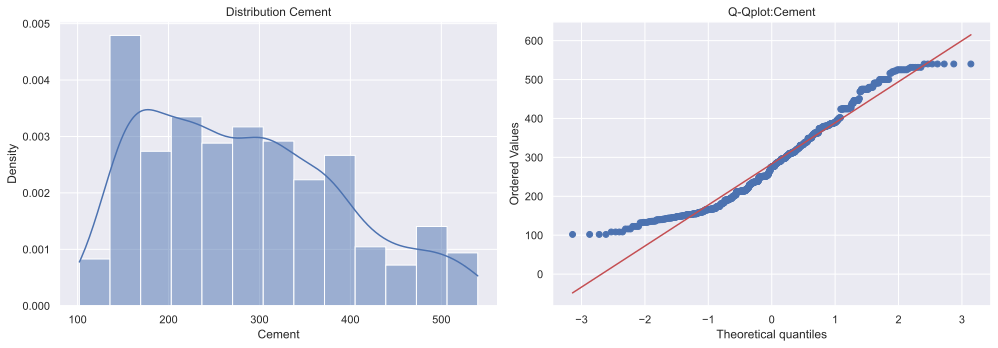

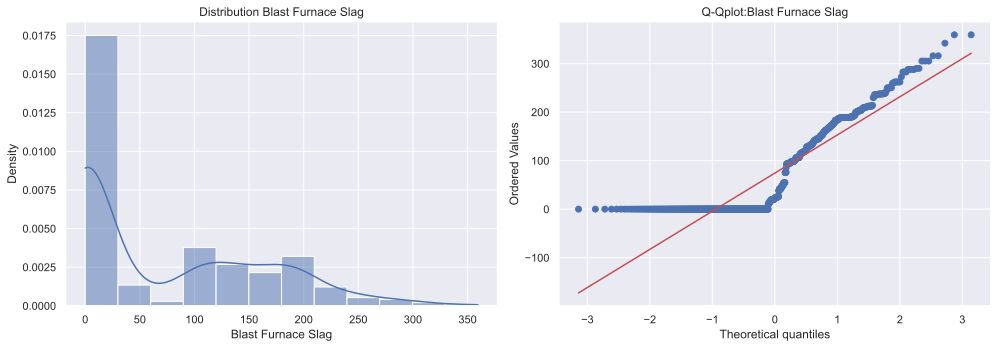

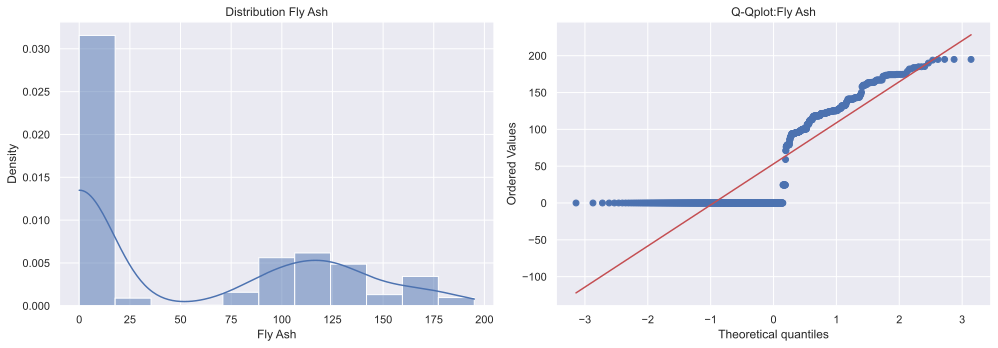

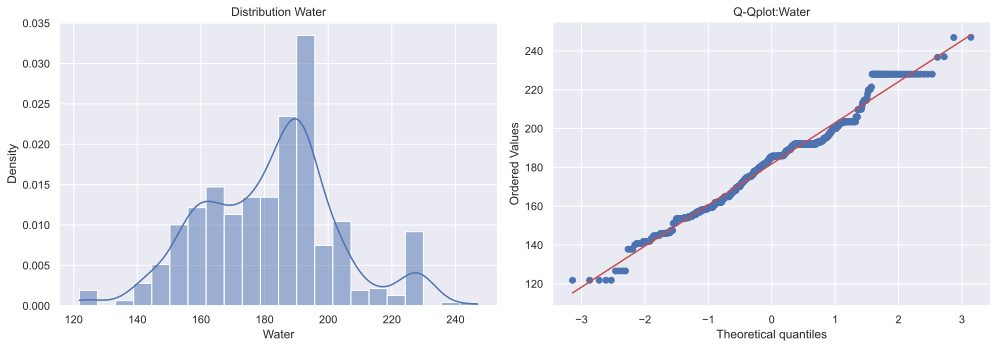

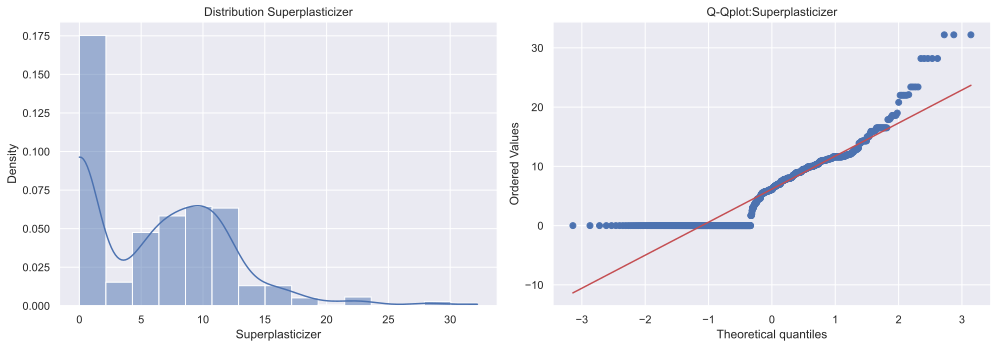

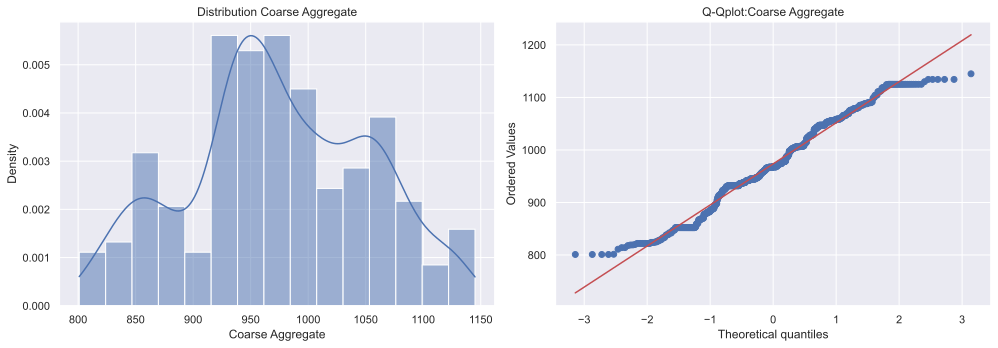

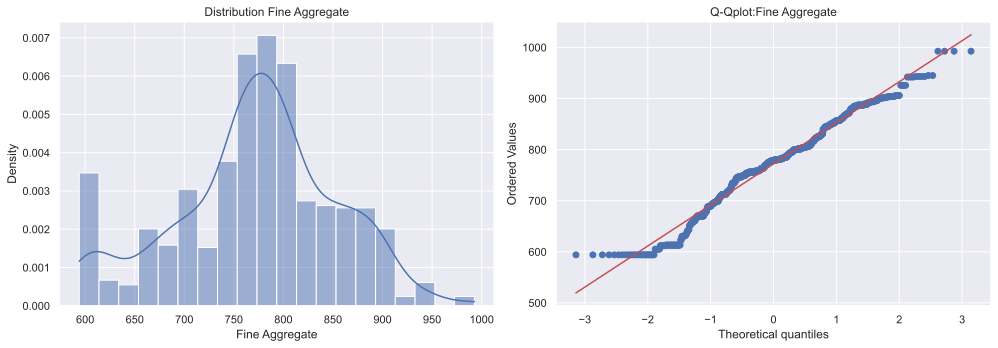

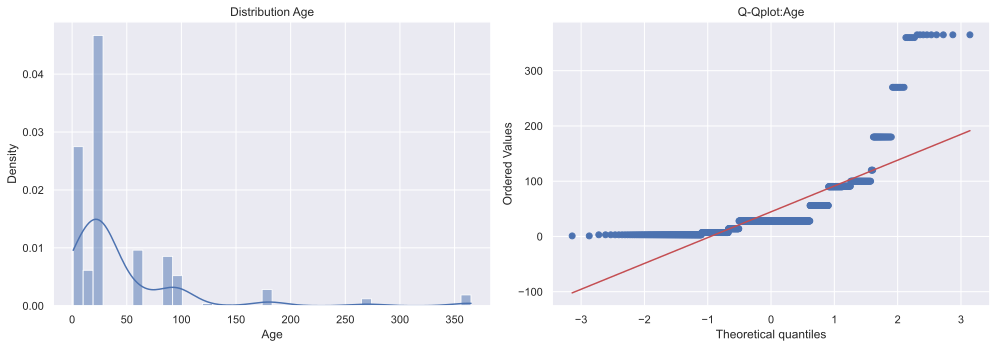

In [26]:
%config InlineBackend.figure_format = 'svg'
numeric_cols = X_train.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    sns.histplot(X_train[col].dropna(),kde=True,stat='density')
    plt.title(f"Distribution {col}")

    plt.subplot(1,2,2)
    stats.probplot(X_train[col].dropna(),dist='norm',plot=plt)
    plt.title(f"Q-Qplot:{col}")

    plt.tight_layout()
    plt.show()

In [27]:
#Applying box cox

pt = PowerTransformer(method='box-cox')

X_train_transform = pt.fit_transform(X_train+0.0000001)
X_test_transform = pt.fit_transform(X_test+0.0000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.215602
1,Blast Furnace Slag,0.023556
2,Fly Ash,-0.005774
3,Water,0.959062
4,Superplasticizer,0.091027
5,Coarse Aggregate,1.192492
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [28]:
lr = LinearRegression()
lr.fit(X_train_transform,y_train)

y_pred2 = lr.predict(X_test_transform)

r2_score(y_test,y_pred2)

0.8050550263362743

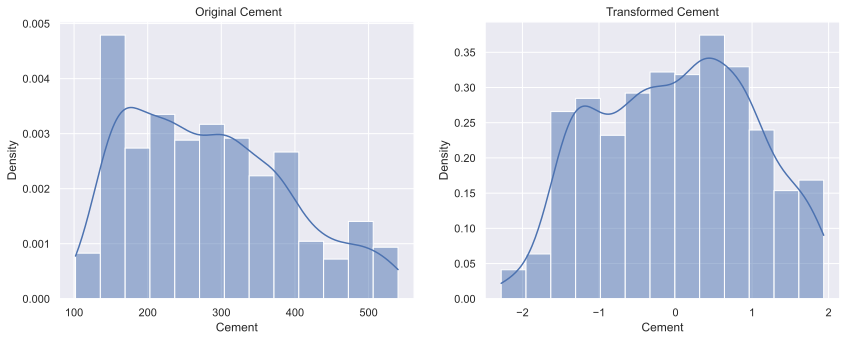

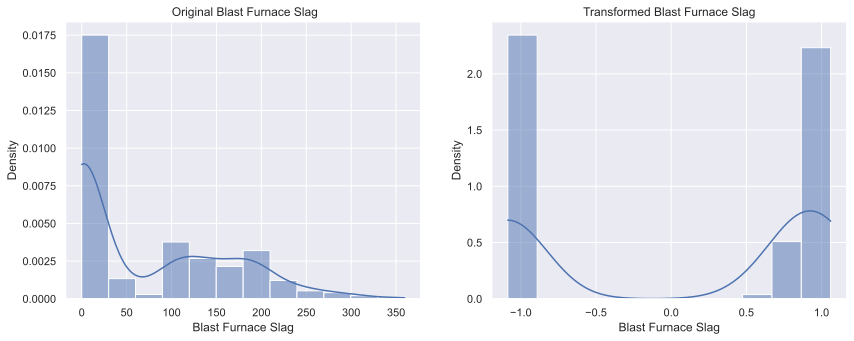

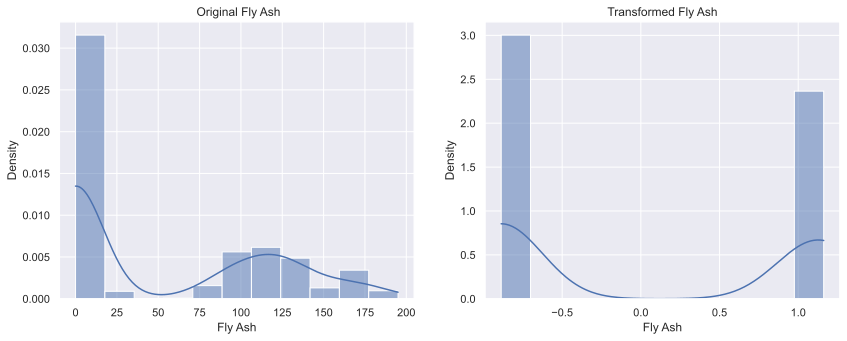

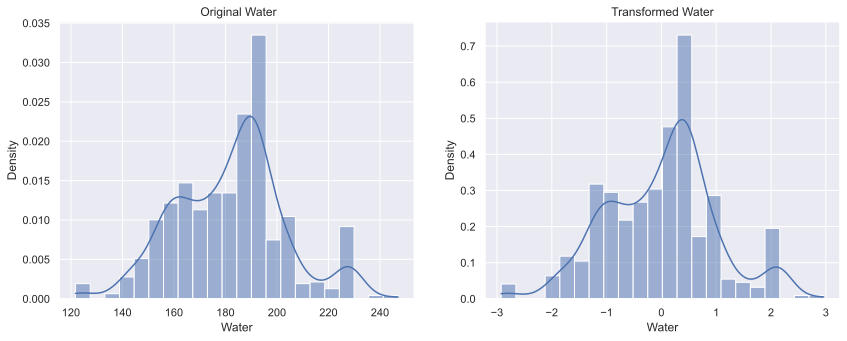

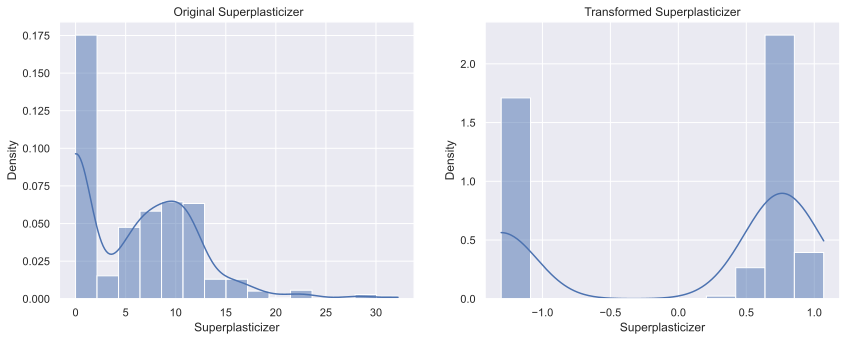

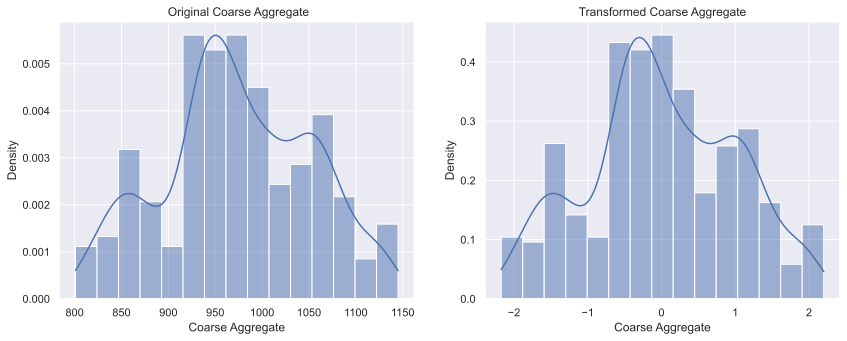

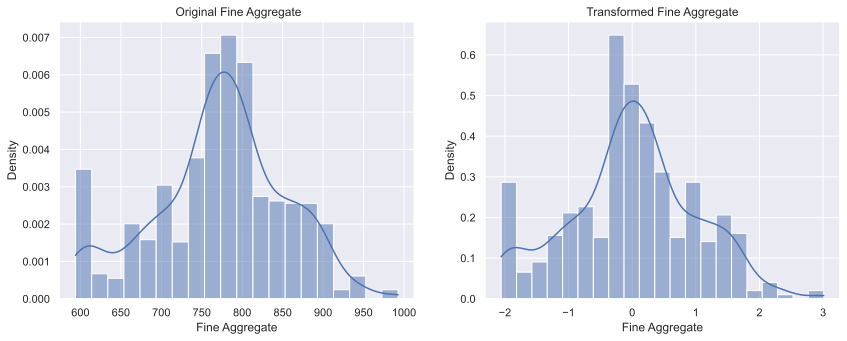

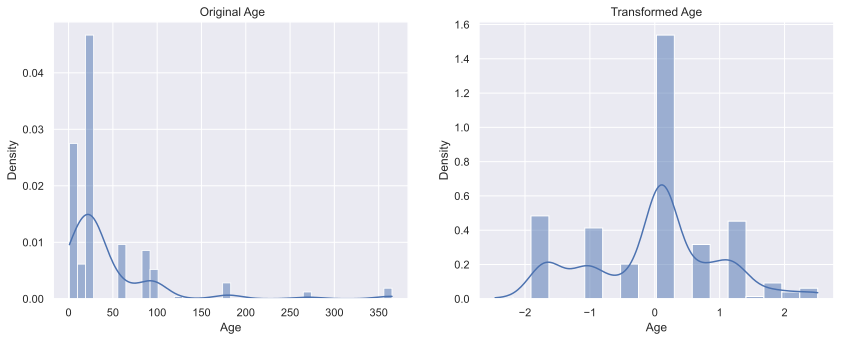

In [29]:
X_train_transform = pd.DataFrame(X_train_transform,columns=X_train.columns)

for col in X_train_transform.columns:
    plt.figure(figsize=(14,5))

    plt.subplot(121)
    sns.histplot(X_train[col],stat='density',kde=True)
    plt.title(f" Original {col}")

    plt.subplot(122)
    sns.histplot(X_train_transform[col],stat="density",kde=True)
    plt.title(f"Transformed {col}")

    plt.show()

In [30]:
pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.fit_transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.8153845513213478


,cols,Yeo_Johnson_lambdas
0,Cement,0.213025
1,Blast Furnace Slag,0.020476
2,Fly Ash,-0.038218
3,Water,0.958936
4,Superplasticizer,0.304951
5,Coarse Aggregate,1.192750
6,Fine Aggregate,1.975085
7,Age,-0.062443
